In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Image size
img_width = 128
img_height = 128
batch_size = 32

# Dataset path
train_dir = "/content/drive/MyDrive/Colab Notebooks/classification /train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/classification /test"

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# Load MobileNetV2 Pretrained Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# Train Model
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

# Evaluate Model
loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Save Model
model.save("interior_design_mobilenetv2.h5")

print("MobileNetV2 model trained successfully!")

Found 4142 images belonging to 4 classes.
Found 2092 images belonging to 4 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.5063 - loss: 1.1809 - val_accuracy: 0.7256 - val_loss: 0.7511
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 54s 417ms/step - accuracy: 0.6036 - loss: 0.9762 - val_accuracy: 0.7376 - val_loss: 0.6909
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 406ms/step - accuracy: 0.6125 - loss: 0.9433 - val_accuracy: 0.7122 - val_loss: 0.7090
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 412ms/step - accuracy: 0.6306 - loss: 0.9030 - val_accuracy: 0.7835 - val_loss: 0.6311
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 408ms/step - accuracy: 0.6359 - loss: 0.8862 - val_accuracy: 0.7749 - val_loss: 0.6011
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 411ms/step - accuracy: 0.6432 - loss: 0.8578 - val_accuracy: 0.7835 - val_loss: 0.5818
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 409ms/step - accuracy: 0.6598 - loss: 0.8507 - val_accuracy: 0.7902 - val_loss: 0.6153
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 54s 414ms/step - accuracy: 0.6601 - loss: 0.8

Test Accuracy: 80.40%
MobileNetV2 model trained successfully!


In [13]:
# Save complete model
model.save("mobilenet_interior_design.h5")

print("Model saved successfully!")

Model saved successfully!


In [15]:
from tensorflow.keras.models import load_model

classifier_model = load_model(
    "/content/drive/MyDrive/Colab Notebooks/mobilenet_interior_design.h5"
)

print("Model Loaded!")

Model Loaded!


In [17]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl", "rb") as f:
    classes = pickle.load(f)

print(classes)

['bathroom', 'bedroom', 'kitchen', 'living_room']


In [19]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl"

print(os.path.getsize(path))

61


In [20]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl"

print(os.path.exists(path))
print(os.path.getsize(path))

True
61


In [21]:
import os

file_path = "/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl"

print("Exists:", os.path.exists(file_path))
print("Size:", os.path.getsize(file_path), "bytes")

Exists: True
Size: 61 bytes


In [22]:
import pickle

classes = [
    "Bedroom",
    "Dining Room",
    "Kitchen",
    "Living Room"
]  # Apne actual class names likho

with open("class_name.pkl", "wb") as f:
    pickle.dump(classes, f)

print("class_name.pkl saved")

class_name.pkl saved


In [23]:
import os
import pickle

train_dir ="/content/drive/MyDrive/Colab Notebooks/classification /train" # apna train folder path

classes = sorted(os.listdir(train_dir))

with open("class_name.pkl", "wb") as f:
    pickle.dump(classes, f)

print(classes)

['bathroom', 'bedroom', 'kitchen', 'living_room']


In [24]:
import os

file_path ="/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl"
print("Exists:", os.path.exists(file_path))
print("Size:", os.path.getsize(file_path))

Exists: True
Size: 61


In [25]:
classes = ['Bedroom', 'Dining Room', 'Kitchen', 'Living Room']

In [26]:
import pickle

classes = ['Bedroom', 'Dining Room', 'Kitchen', 'Living Room']

with open('/content/class_name.pkl', 'wb') as f:
    pickle.dump(classes, f)

print("Saved successfully")

Saved successfully


In [27]:
with open('/content/class_name.pkl', 'rb') as f:
    classes = pickle.load(f)

print(classes)

['Bedroom', 'Dining Room', 'Kitchen', 'Living Room']


In [28]:
import os
import pickle

train_dir = "/content/drive/MyDrive/Colab Notebooks/classification /train"   # apna path

classes = sorted(os.listdir(train_dir))

with open('/content/class_name.pkl', 'wb') as f:
    pickle.dump(classes, f)

print(classes)


['bathroom', 'bedroom', 'kitchen', 'living_room']


In [29]:
import os
import pickle

train_dir = "/content/drive/MyDrive/Colab Notebooks/classification /train"

# Class names read karo
classes = sorted(os.listdir(train_dir))

print("Classes found:", classes)

# class_name.pkl overwrite karo
with open("/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl", "wb") as f:
    pickle.dump(classes, f)

print("class_name.pkl recreated successfully")

Classes found: ['bathroom', 'bedroom', 'kitchen', 'living_room']
class_name.pkl recreated successfully


In [32]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl", "rb") as f:
    classes = pickle.load(f)


print(classes)

['bathroom', 'bedroom', 'kitchen', 'living_room']


In [33]:
import os

train_dir = "/content/drive/MyDrive/Colab Notebooks/classification /train"

for item in os.listdir(train_dir):
    print(item)

living_room
kitchen
bathroom
bedroom


In [34]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/classification /classification.pkl", "rb") as f:
    classes = pickle.load(f)

print(classes)

['bathroom', 'bedroom', 'kitchen', 'living_room']


In [35]:
from tensorflow.keras.models import load_model

room_classifier = load_model(
    "/content/drive/MyDrive/Colab Notebooks/mobilenet_interior_design.h5"
)

In [37]:
import numpy as np
from tensorflow.keras.preprocessing import image

class_names = list(train_data.class_indices.keys())

def predict_room(img_path):

    img = image.load_img(
        img_path,
        target_size=(128,128)
    )

    img = image.img_to_array(img)
    img = img/255.0
    img = np.expand_dims(img, axis=0)

    pred = room_classifier.predict(img)

    room = class_names[np.argmax(pred)]

    return room

In [38]:
!pip install transformers diffusers accelerate torch sentencepiece -q

In [39]:
!pip install -q transformers accelerate torch

In [40]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model Loaded Successfully!")

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model Loaded Successfully!


In [41]:
!pip install -q transformers accelerate torch

In [42]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto"
)

print("Model Loaded Successfully!")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model Loaded Successfully!


In [44]:
import torch

prompt = "Suggest a modern interior design for a bedroom."

messages = [
    {
        "role": "user",
        "content": prompt
    }
]

formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True,
    top_p=0.9
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|user|>
Suggest a modern interior design for a bedroom.
<|assistant|>
To create a modern interior design for a bedroom, here are some suggestions:

1. Use white or light-colored walls for a clean and fresh look.

2. Use geometric patterns or bold colors on the walls and furniture to add visual interest.

3. Incorporate natural materials such as wood, stone, or metal for a rustic or earthy feel.

4. Choose sleek, modern furniture with clean lines and minimal decor.

5. Add touches of texture with throw pillows, area rugs, or blankets in earthy tones and neutral colors.

6. Use lighting to create a warm, inviting atmosphere. Layered pendant lights or floor lamps can create a cozy, intimate feel.

7. Opt for a minimalist bedding and curtains for a sleek, modern look.

8. Incorporate colorful


In [45]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

True
1


In [46]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch Version: 2.11.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU: Tesla T4


In [47]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [48]:
import torch

prompt = """
Suggest a modern interior design for a bedroom.
Include:
1. Color scheme
2. Furniture
3. Lighting
4. Decorations
"""

messages = [
    {"role": "user", "content": prompt}
]

formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    formatted_prompt,
    return_tensors="pt"
).to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=300,
    temperature=0.7,
    do_sample=True,
    top_p=0.9
)

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(response)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|user|>

Suggest a modern interior design for a bedroom.
Include:
1. Color scheme
2. Furniture
3. Lighting
4. Decorations

<|assistant|>
To create a modern and stylish interior design for a bedroom, here are some suggestions:

1. Color Scheme: Choose a neutral color palette with muted tones like beige, grey, and white. This will create a calming and relaxing atmosphere.

2. Furniture: Choose furniture pieces that are sleek and modern. A bed, a dresser, and a coffee table with storage will provide ample storage and space for your belongings. Consider adding a small sofa or a chic armchair for extra seating.

3. Lighting: Use pendant lighting for a statement piece and accent lighting to highlight your furniture. A dimmer switch can also be used to adjust the lighting level according to your mood.

4. Decorations: Incorporate modern decor elements like sculptures, abstract art, and contemporary artwork to create a cohesive and stylish look. Consider incorporating a modern headboard with 

In [49]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("TinyLlama Loaded Successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TinyLlama Loaded Successfully!


In [50]:
prompt = "Suggest a modern interior design for a bedroom."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.7,
    do_sample=True
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(response)

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Suggest a modern interior design for a bedroom.

8. SleepEasy: A smart mattress that adjusts to the sleeper's body shape and temperature, reducing the risk of snoring and ear infections.

9. SleepMate: A smart mattress that controls the temperature, noise, and lighting in the bedroom, providing a relaxing and comfortable sleep experience.

10. SleepYard: A smart bed that tracks the sleep patterns and alerts the user with notifications and suggestions for improving the quality of their sleep.


In [51]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [52]:
prompt = "Give 5 interior design tips for a modern bedroom."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    do_sample=True
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Give 5 interior design tips for a modern bedroom. 5. Simple Pleasures: Simple Pleasures is a blog with some great design tips for small spaces. 6. Apartment Therapy: If you're looking for apartment decorating ideas, Apartment Therapy is a great resource. 7. The Coffee Shop Project: The Coffee Shop Project is a great blog for finding inspiration for small-space living. 8. Buzzfeed: Buzzfeed has a variety of design guides


In [53]:
prompt = "Suggest wall colors for a luxury living room."

In [54]:
prompt = "How can I decorate a small kitchen on a low budget?"

In [56]:
prompt = "Design a modern office room with minimal furniture."

In [57]:
!pip install diffusers transformers accelerate torch -q


In [58]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

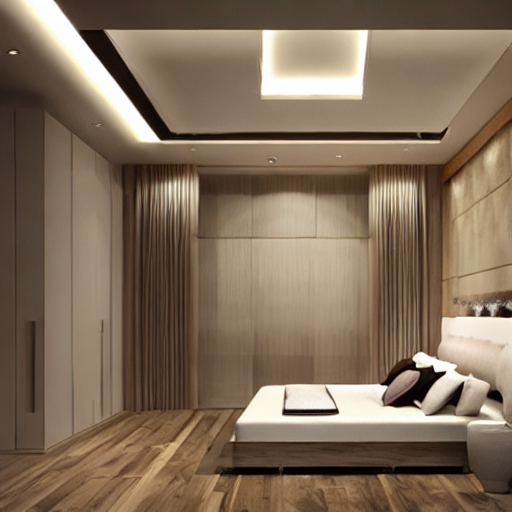

In [59]:
prompt = "Modern luxury bedroom interior design, elegant lighting, wooden floor, high quality"

image = pipe(prompt).images[0]

image.save("generated_room.png")

image

In [60]:
# Image Generate
prompt = "Modern luxury bedroom interior design, elegant lighting, wooden floor, high quality"

image = pipe(prompt).images[0]

# Google Drive me save
save_path = "/content/drive/MyDrive/Colab Notebooks/generated_room.png"
image.save(save_path)

print("Image saved at:", save_path)

  0%|          | 0/50 [00:00<?, ?it/s]

Image saved at: /content/drive/MyDrive/Colab Notebooks/generated_room.png


In [61]:
# Model save
model.save_pretrained("my_llama_model")

# Tokenizer save (agar tokenizer use kiya hai)
tokenizer.save_pretrained("my_llama_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_llama_model/tokenizer_config.json',
 'my_llama_model/chat_template.jinja',
 'my_llama_model/tokenizer.json')

In [62]:
!zip -r my_llama_model.zip my_llama_model

  adding: my_llama_model/ (stored 0%)
  adding: my_llama_model/tokenizer.json (deflated 85%)
  adding: my_llama_model/generation_config.json (deflated 29%)
  adding: my_llama_model/model.safetensors (deflated 23%)
  adding: my_llama_model/config.json (deflated 49%)
  adding: my_llama_model/tokenizer_config.json (deflated 46%)
  adding: my_llama_model/chat_template.jinja (deflated 60%)


In [72]:
from google.colab import files

files.download("my_llama_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
!pip install flask pyngrok


In [75]:
from pyngrok import ngrok

ngrok.set_auth_token("3F5ObBEYNa9Ul1FcetQz3YLALzM_6qWMD1zaDigzo85dQwXME")

In [77]:
from flask import Flask, jsonify

app = Flask(__name__)

@app.route("/")
def home():
    return "Flask server is running!"

@app.route("/generate", methods=["GET"])
def generate():
    return jsonify({
        "message": "API working successfully 🚀"
    })

In [78]:
import threading

def run_app():
    app.run(port=5000)

# Start Flask in background thread
threading.Thread(target=run_app).start()

# Start ngrok tunnel
public_url = ngrok.connect(5000)
print("Public URL:", public_url)

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Public URL: NgrokTunnel: "https://unsold-sternness-polka.ngrok-free.dev" -> "http://localhost:5000"
